In [1]:
import udkm1Dsim as ud
u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

In [2]:
Cr = ud.Atom('Cr')
Si = ud.Atom('Si')

In [3]:
density_Cr = 7140*u.kg/u.m**3

prop_Cr = {}
prop_Cr['heat_capacity'] = 449*u.J/u.kg/u.K
prop_Cr['therm_cond'] = 94*u.W/(u.m*u.K)
prop_Cr['lin_therm_exp'] = 6.2e-6
prop_Cr['sound_vel'] = 5.940*u.nm/u.ps
prop_Cr['opt_ref_index'] = 3.1612+3.4606j
prop_Cr['opt_ref_index_per_strain'] = 0+0j

layer_Cr = ud.AmorphousLayer('Cr', "Cr amorphous", 1*u.nm, density_Cr/3, atom=Cr, **prop_Cr)

In [4]:
density_Si = 2336*u.kg/u.m**3

prop_Si = {}
prop_Si['heat_capacity'] = 703*u.J/u.kg/u.K
prop_Si['therm_cond'] = 150*u.W/(u.m*u.K)
prop_Si['lin_therm_exp'] = 2.6e-6
prop_Si['sound_vel'] = 8.433*u.nm/u.ps
prop_Si['opt_ref_index'] = 3.6941+0j
prop_Si['opt_ref_index_per_strain'] = 1+0j

layer_Si = ud.AmorphousLayer('Si', "Si amorphous", 1*u.nm, density_Si, atom=Si, **prop_Si)

In [5]:
S = ud.Structure('Fe/Cr AFM Super Lattice')

S.add_sub_structure(layer_Cr, 100)
S.add_sub_structure(layer_Si, 5000)

In [6]:
h = ud.Heat(S, True)

h.save_data = False
h.disp_messages = True

h.excitation = {'fluence': [40]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [1]*u.ps,
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 45*u.deg}

# enable heat diffusion
h.heat_diffusion = False

# temporal and spatial grid
delays = np.r_[-2:400:10]*u.ps
_, _, distances = S.get_distances_of_layers()

In [7]:
temp_map, delta_temp_map = h.get_temp_map(delays, 0*u.K)

Surface incidence fluence scaled by factor 0.7071 due to incidence angle theta=45.00 deg
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 45.0 % and transmission of 0.4 %.
Elapsed time for _temperature_after_delta_excitation_: 0.053799 s
Elapsed time for _temp_map_: 0.070452 s


/home/schick/Programming/git/udkm1Dsim/udkm1Dsim/simulations/heat.py:292: UserWarning: The effect of finite pulse duration of the excitation is only considered if heat diffusion is enabled! All pulse durations are set to 0!
  warnings.warn('The effect of finite pulse duration of the excitation '


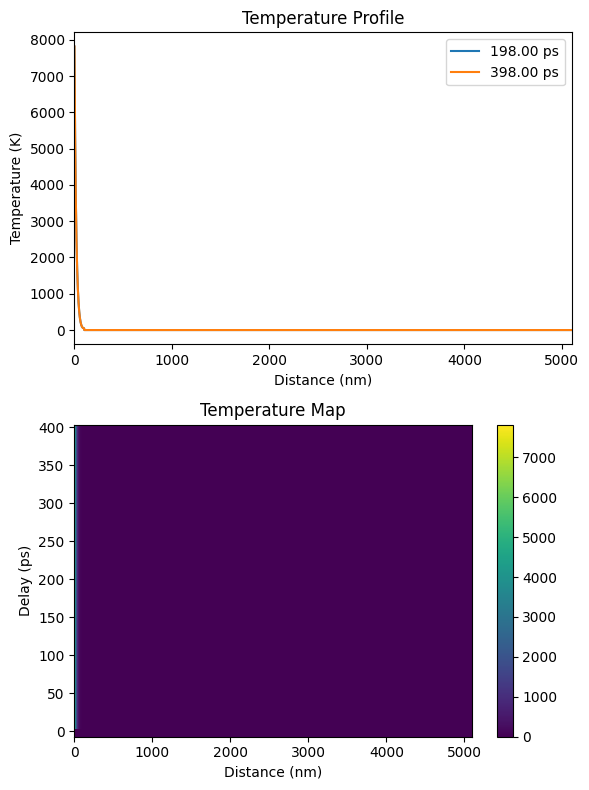

In [8]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(distances.to('nm').magnitude, temp_map[20, :],
         label='{:0.2f} ps'.format(delays[20].to('ps').magnitude))
plt.plot(distances.to('nm').magnitude, temp_map[-1, :],
         label='{:0.2f} ps'.format(delays[-1].to('ps').magnitude))
plt.xlim([0, distances.to('nm').magnitude[-1]])
plt.xlabel('Distance (nm)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.title('Temperature Profile')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map, shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Temperature Map')

plt.tight_layout()
plt.show()

In [9]:
p = ud.PhononNum(S, True)
p.save_data = False
p.disp_messages = True

In [ ]:
strain_map = p.get_strain_map(delays, temp_map, delta_temp_map)

In [ ]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(distances.to('nm').magnitude, strain_map[30, :], label=np.round(delays[30]))
plt.plot(distances.to('nm').magnitude, strain_map[-1, :], label=np.round(delays[-1]))
plt.xlim([0, distances.to('nm').magnitude[-1]])
plt.xlabel('Distance (nm)')
plt.ylabel('Strain')
plt.legend()
plt.title('Strain Profile')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,
               strain_map, cmap='RdBu', vmin=-np.max(strain_map),
               vmax=np.max(strain_map), shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Strain Map')

plt.tight_layout()
plt.show()

In [12]:
light = ud.Light(S, True)
light.disp_messages = True
light.save_data = False
light.set_incoming_polarization(3)

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
incoming polarizations set to: sigma


In [13]:
light.energy = np.r_[1:3:0.1]*u.eV  # set two photon energies
light.theta = np.r_[1:90:1]*u.deg  # theta range
# this is the actual calculation
R, T = light.homogeneous_reflectivity()

In [14]:
R.shape

(20, 89)

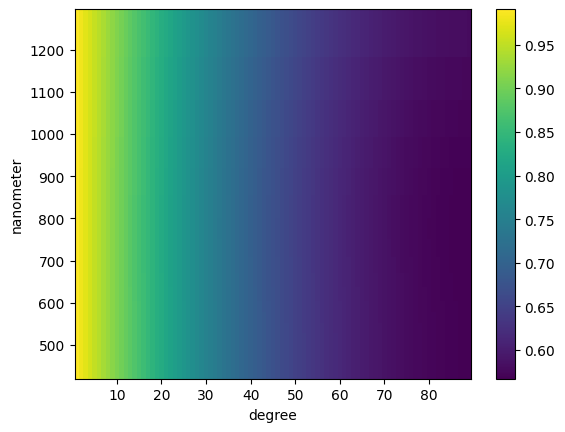

In [15]:
plt.figure()
plt.pcolormesh(light.theta[0, :], light.wl, R)

plt.colorbar()

plt.show()

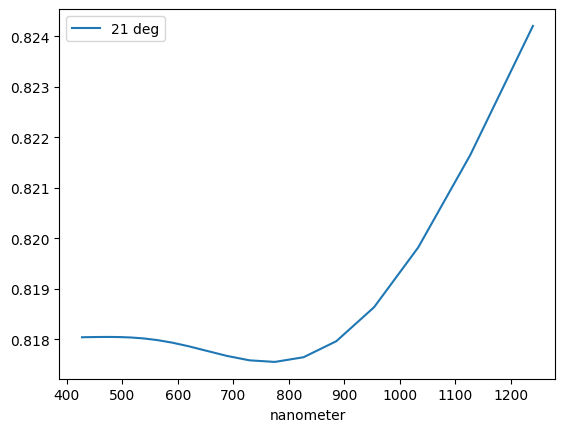

In [16]:
plt.figure()
idx = 20
plt.plot(light.wl, R[:, idx], label=light.theta[0, idx])
plt.legend()
plt.show()



In [ ]:
light.energy = np.r_[1:3:0.01]*u.eV  # set two photon energies
light.theta = np.r_[45]*u.deg  # theta range

R_inhom, T_inhom = light.inhomogeneous_reflectivity(strain_map)

SyntaxError: 'break' outside loop (2974451401.py, line 1)

In [ ]:
R_inhom

array([[[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]],

       [[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]],

       [[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]],

       ...,

       [[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]],

       [[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]],

       [[0.45375093],
        [0.45375093],
        [0.45375093],
        ...,
        [0.45375093],
        [0.45375093],
        [0.45375093]]], shape=(41, 200, 1))

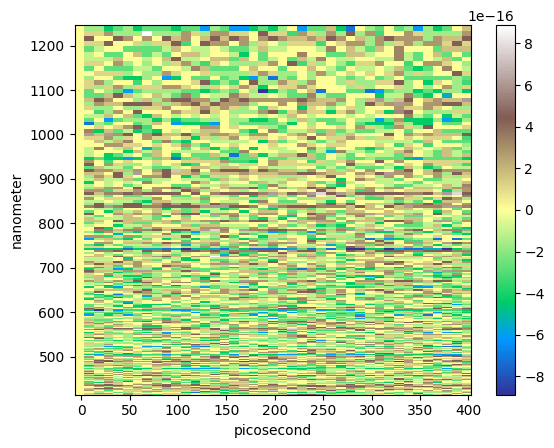

In [ ]:
plt.figure()
plt.pcolormesh(delays, light.wl, (R_inhom[:, :, 0]-R_inhom[0, :, 0]).T, cmap='terrain')

plt.colorbar()


plt.show()

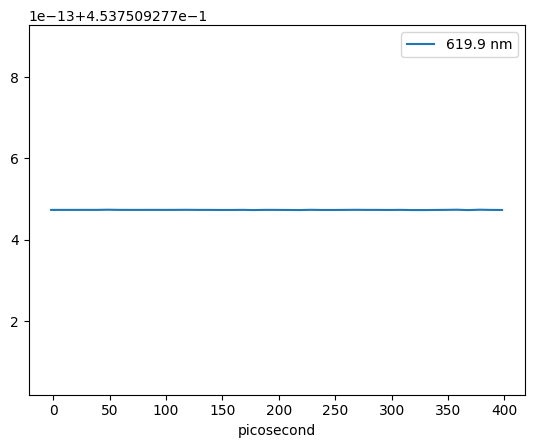

In [ ]:
plt.figure()
idx = 100
plt.plot(delays, R_inhom[:, idx, 0].T, label=light.wl[idx])
plt.legend()
plt.show()

In [ ]:
alpha = np.ones((10, 20, 30), dtype=complex)

In [ ]:
ref_indices = np.ones(30)

In [ ]:
result = np.einsum('ij,k', alpha[:, :, 0], ref_indices)

In [ ]:
alpha.shape

(10, 20, 30)

In [ ]:
result.shape

(10, 20, 30)